# Automated Multi-Database Collection & Rule-Based Screening
## Systematic Review: Anti-CD20 mAbs (Ocrelizumab, Ofatumumab, Ublituximab) for RRMS
### Primary outcome: ARR | Comparators: IFN-β1a OR Teriflunomide

---

### What this notebook does
**Section 1** Install dependencies  
**Section 2** Fetch records from PubMed/MEDLINE via Entrez API  
**Section 3** Fetch records from Cochrane CENTRAL via REST API  
**Section 4** Fetch records from OpenAlex (broad academic coverage)  
**Section 5** Fetch trials from ClinicalTrials.gov  
**Section 6** Merge all sources & deduplicate by title/DOI/PMID  
**Section 7** Rule-based PICO screening  
**Section 8** Manual review of UNCERTAIN records  
**Section 9** Export results, PRISMA counts, audit trail, methods paragraph  
**Section 10** Visualise results  

---
### PICO
| | |
|---|---|
| **Population** | Adults with RRMS (McDonald criteria) |
| **Intervention** | Ocrelizumab, Ofatumumab, or Ublituximab (monotherapy) |
| **Comparator** | IFN-β1a (interferon beta-1a) OR Teriflunomide |
| **Outcome** | Annualised Relapse Rate (ARR) |
| **Design** | RCT only, ≥24 weeks follow-up |

> **Heterogeneity note:** IFN-β1a and teriflunomide differ in efficacy tier. Comparator type
> is pre-specified as a subgroup variable in the forest plot (Section 9). This must be
> reported in your Methods and addressed in your Discussion.

## Section 1 — Install & Import

In [ ]:
!pip install biopython pandas openpyxl matplotlib requests tqdm -q

import pandas as pd
import requests
import re
import json
import time
import hashlib
import os
from tqdm import tqdm
from Bio import Entrez
from IPython.display import display
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── CONFIGURE YOUR EMAIL (required by NCBI for Entrez) ────────────────────
# NCBI requires an email for API access. Use your university email.
# This is not a login — it's just a contact field for NCBI rate-limiting.
Entrez.email = "your.email@university.ac.uk"   # <-- CHANGE THIS

# Optional: NCBI API key (free from https://www.ncbi.nlm.nih.gov/account/)
# With key: 10 requests/sec. Without: 3 requests/sec.
NCBI_API_KEY = None   # e.g. "abc123def456..." or leave as None
if NCBI_API_KEY:
    Entrez.api_key = NCBI_API_KEY

print('✓ All packages loaded')
print(f'  Entrez email: {Entrez.email}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 25.5 MB/s eta 0:00:00
✓ All packages loaded
  Entrez email: your.email@university.ac.uk


## Section 2: Fetch from PubMed / MEDLINE

In [ ]:
PUBMED_QUERY = """(
  "relapsing remitting multiple sclerosis"[MeSH Terms]
  OR "relapsing-remitting multiple sclerosis"[Title/Abstract]
  OR "RRMS"[Title/Abstract]
  OR "relapsing multiple sclerosis"[Title/Abstract]
)
AND (
  "ocrelizumab"[Title/Abstract]
  OR "ofatumumab"[Title/Abstract]
  OR "ublituximab"[Title/Abstract]
  OR "ocrevus"[Title/Abstract]
  OR "kesimpta"[Title/Abstract]
  OR "briumvi"[Title/Abstract]
  OR "anti-CD20"[Title/Abstract]
  OR "CD20 monoclonal antibody"[Title/Abstract]
)
AND (
  "interferon beta-1a"[Title/Abstract]
  OR "interferon beta 1a"[Title/Abstract]
  OR "IFN-beta-1a"[Title/Abstract]
  OR "IFN-b1a"[Title/Abstract]
  OR "Avonex"[Title/Abstract]
  OR "Rebif"[Title/Abstract]
  OR "teriflunomide"[Title/Abstract]
  OR "Aubagio"[Title/Abstract]
)
AND (
  "randomized controlled trial"[Publication Type]
  OR "randomised controlled trial"[Title/Abstract]
  OR "randomized controlled trial"[Title/Abstract]
  OR "RCT"[Title/Abstract]
)"""

MAX_RECORDS = 500  # increase if needed

def fetch_pubmed(query, max_records=500):
    print('Searching PubMed...')
    # Search
    handle = Entrez.esearch(db='pubmed', term=query,
                            retmax=max_records, usehistory='y')
    search_results = Entrez.read(handle)
    handle.close()

    count   = int(search_results['Count'])
    webenv  = search_results['WebEnv']
    qkey    = search_results['QueryKey']
    print(f'  Found {count} records on PubMed (fetching up to {max_records})')

    if count == 0:
        return []

    # Fetch in batches of 100
    records = []
    batch_size = 100
    for start in range(0, min(count, max_records), batch_size):
        handle = Entrez.efetch(
            db='pubmed', rettype='xml', retmode='xml',
            retstart=start, retmax=batch_size,
            webenv=webenv, query_key=qkey
        )
        batch = Entrez.read(handle)
        handle.close()
        time.sleep(0.4)

        for article in batch.get('PubmedArticle', []):
            try:
                med  = article['MedlineCitation']
                art  = med['Article']
                pmid = str(med['PMID'])

                title = str(art.get('ArticleTitle', ''))

                abstract = ''
                if 'Abstract' in art:
                    ab_texts = art['Abstract'].get('AbstractText', [])
                    if isinstance(ab_texts, list):
                        abstract = ' '.join([str(t) for t in ab_texts])
                    else:
                        abstract = str(ab_texts)

                authors = ''
                if 'AuthorList' in art:
                    try:
                        first = art['AuthorList'][0]
                        authors = f"{first.get('LastName','')}, {first.get('ForeName','')}"
                    except:
                        pass

                year = ''
                try:
                    year = str(art['Journal']['JournalIssue']['PubDate'].get('Year', ''))
                except:
                    pass

                journal = ''
                try:
                    journal = str(art['Journal']['Title'])
                except:
                    pass

                doi = ''
                for loc in article.get('PubmedData', {}).get('ArticleIdList', []):
                    if str(loc.attributes.get('IdType','')) == 'doi':
                        doi = str(loc)
                        break

                records.append({
                    'source': 'PubMed',
                    'pmid': pmid,
                    'doi': doi,
                    'title': title,
                    'abstract': abstract,
                    'authors': authors,
                    'year': year,
                    'journal': journal,
                })
            except Exception as e:
                continue

    print(f'  ✓ Fetched {len(records)} PubMed records')
    return records


pubmed_records = fetch_pubmed(PUBMED_QUERY, MAX_RECORDS)
df_pubmed = pd.DataFrame(pubmed_records)
print(f'  PubMed dataframe: {df_pubmed.shape[0]} rows')

Searching PubMed...
  Found 17 records on PubMed (fetching up to 500)
  ✓ Fetched 17 PubMed records
  PubMed dataframe: 17 rows


## Section 3 — Fetch from Cochrane CENTRAL

In [ ]:
def fetch_cochrane(max_records=200):
    """
    Fetches from Cochrane CENTRAL via the public REST API.
    No login required. Returns list of record dicts.
    Docs: https://rest.cochrane.org/
    """
    print('Searching Cochrane CENTRAL...')
    base_url = 'https://rest.cochrane.org/search'

    # Cochrane uses a simple keyword query
    query_terms = (
        '(ocrelizumab OR ofatumumab OR ublituximab OR "anti-CD20") '
        'AND ("relapsing remitting multiple sclerosis" OR RRMS) '
        'AND ("interferon beta-1a" OR "IFN-beta-1a" OR teriflunomide)'
    )

    records = []
    page     = 1
    per_page = 50

    while len(records) < max_records:
        params = {
            'q':        query_terms,
            'page':     page,
            'per_page': per_page,
            'type':     'trial',  # CENTRAL trials only
        }
        try:
            resp = requests.get(base_url, params=params, timeout=20)
            if resp.status_code == 404 or resp.status_code == 400:
                print(f'  Cochrane API returned {resp.status_code} — trying fallback query')
                break
            resp.raise_for_status()
            data = resp.json()
        except Exception as e:
            print(f'  Cochrane fetch error: {e}')
            break

        results = data.get('results', data.get('items', []))
        if not results:
            break

        for item in results:
            records.append({
                'source':   'Cochrane',
                'pmid':     item.get('pmid', ''),
                'doi':      item.get('doi', ''),
                'title':    item.get('title', ''),
                'abstract': item.get('abstract', item.get('description', '')),
                'authors':  ', '.join(item.get('authors', [])) if isinstance(item.get('authors'), list) else item.get('authors', ''),
                'year':     str(item.get('year', item.get('publication_year', ''))),
                'journal':  item.get('journal', item.get('source', '')),
            })

        total = data.get('total', data.get('total_results', 0))
        print(f'  Page {page}: {len(results)} results (total reported: {total})')

        if len(records) >= total or len(results) < per_page:
            break
        page += 1
        time.sleep(1.0)

    print(f'  ✓ Fetched {len(records)} Cochrane records')
    return records


cochrane_records = fetch_cochrane(200)
df_cochrane = pd.DataFrame(cochrane_records) if cochrane_records else pd.DataFrame(
    columns=['source','pmid','doi','title','abstract','authors','year','journal'])
print(f'  Cochrane dataframe: {df_cochrane.shape[0]} rows')

Searching Cochrane CENTRAL...
  Cochrane fetch error: HTTPSConnectionPool(host='rest.cochrane.org', port=443): Max retries exceeded with url: /search?q=%28ocrelizumab+OR+ofatumumab+OR+ublituximab+OR+%22anti-CD20%22%29+AND+%28%22relapsing+remitting+multiple+sclerosis%22+OR+RRMS%29+AND+%28%22interferon+beta-1a%22+OR+%22IFN-beta-1a%22+OR+teriflunomide%29&page=1&per_page=50&type=trial (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7c571655d790>: Failed to resolve 'rest.cochrane.org' ([Errno -2] Name or service not known)"))
  ✓ Fetched 0 Cochrane records
  Cochrane dataframe: 0 rows


## Section 4 — Fetch from OpenAlex

OpenAlex is a fully open academic index (successor to Microsoft Academic Graph).  
No API key required. Covers 250M+ works including many not indexed in PubMed.

In [ ]:
def fetch_openalex(max_records=200):
    """
    Fetches from OpenAlex API using title/abstract keyword search.
    Docs: https://docs.openalex.org/
    """
    print('Searching OpenAlex...')
    base_url = 'https://api.openalex.org/works'

    # OpenAlex uses title_and_abstract.search for full-text keyword matching
    search_terms = [
        'ocrelizumab relapsing multiple sclerosis interferon randomized',
        'ocrelizumab relapsing multiple sclerosis teriflunomide randomized',
        'ofatumumab relapsing multiple sclerosis interferon randomized',
        'ofatumumab relapsing multiple sclerosis teriflunomide randomized',
        'ublituximab relapsing multiple sclerosis interferon randomized',
        'ublituximab relapsing multiple sclerosis teriflunomide randomized',
    ]

    all_records = []
    seen_ids    = set()

    for term in search_terms:
        page     = 1
        per_page = 50

        while len(all_records) < max_records:
            params = {
                'search':   term,
                'filter':   'type:article',
                'per_page': per_page,
                'page':     page,
                'select':   'id,doi,title,abstract_inverted_index,authorships,publication_year,primary_location',
                'mailto':   Entrez.email,
            }
            try:
                resp = requests.get(base_url, params=params, timeout=20)
                resp.raise_for_status()
                data = resp.json()
            except Exception as e:
                print(f'  OpenAlex error for "{term}": {e}')
                break

            results = data.get('results', [])
            if not results:
                break

            for item in results:
                oa_id = item.get('id', '')
                if oa_id in seen_ids:
                    continue
                seen_ids.add(oa_id)

                # Reconstruct abstract from inverted index
                abstract = ''
                inv_idx = item.get('abstract_inverted_index')
                if inv_idx:
                    try:
                        word_positions = [(word, pos)
                                          for word, positions in inv_idx.items()
                                          for pos in positions]
                        word_positions.sort(key=lambda x: x[1])
                        abstract = ' '.join([w for w, _ in word_positions])
                    except:
                        pass

                # Authors
                authors = ''
                try:
                    authorships = item.get('authorships', [])
                    if authorships:
                        authors = authorships[0].get('author', {}).get('display_name', '')
                except:
                    pass

                # Journal
                journal = ''
                try:
                    journal = item.get('primary_location', {}).get('source', {}).get('display_name', '')
                except:
                    pass

                doi = str(item.get('doi', '')).replace('https://doi.org/', '')

                all_records.append({
                    'source':   'OpenAlex',
                    'pmid':     '',
                    'doi':      doi,
                    'title':    item.get('title', ''),
                    'abstract': abstract,
                    'authors':  authors,
                    'year':     str(item.get('publication_year', '')),
                    'journal':  journal,
                })

            total = data.get('meta', {}).get('count', 0)
            if len(results) < per_page or page * per_page >= total:
                break
            page += 1
            time.sleep(0.5)

    print(f'  ✓ Fetched {len(all_records)} OpenAlex records')
    return all_records


openalex_records = fetch_openalex(200)
df_openalex = pd.DataFrame(openalex_records) if openalex_records else pd.DataFrame(
    columns=['source','pmid','doi','title','abstract','authors','year','journal'])
print(f'  OpenAlex dataframe: {df_openalex.shape[0]} rows')

Searching OpenAlex...
  ✓ Fetched 200 OpenAlex records
  OpenAlex dataframe: 200 rows


## Section 5 — Fetch from ClinicalTrials.gov

In [ ]:
def fetch_clinicaltrials(max_records=100):
    """
    Fetches from ClinicalTrials.gov v2 API.
    Returns trials with posted results (important for unpublished outcome data).
    Docs: https://clinicaltrials.gov/data-api/api
    """
    print('Searching ClinicalTrials.gov...')
    base_url = 'https://clinicaltrials.gov/api/v2/studies'

    queries = [
        'ocrelizumab relapsing multiple sclerosis',
        'ofatumumab relapsing multiple sclerosis',
        'ublituximab relapsing multiple sclerosis',
    ]

    all_records = []
    seen_ncts   = set()

    for q in queries:
        params = {
            'query.term':   q,
            'filter.overallStatus': 'COMPLETED',
            'aggFilters':   'studyType:int,phase:3 4',
            'pageSize':     max_records,
            'format':       'json',
            'fields':       'NCTId,BriefTitle,OfficialTitle,BriefSummary,DetailedDescription,'
                            'OverallStatus,Phase,StudyType,StartDate,CompletionDate,'
                            'EnrollmentCount,InterventionName,ArmGroupDescription,'
                            'PrimaryOutcomeMeasure,SecondaryOutcomeMeasure,HasResults',
        }
        try:
            resp = requests.get(base_url, params=params, timeout=30)
            resp.raise_for_status()
            data = resp.json()
        except Exception as e:
            print(f'  ClinicalTrials error for "{q}": {e}')
            continue

        studies = data.get('studies', [])
        for study in studies:
            try:
                proto   = study.get('protocolSection', {})
                id_mod  = proto.get('identificationModule', {})
                nct_id  = id_mod.get('nctId', '')

                if nct_id in seen_ncts:
                    continue
                seen_ncts.add(nct_id)

                title   = id_mod.get('officialTitle', id_mod.get('briefTitle', ''))
                summary = proto.get('descriptionModule', {}).get('briefSummary', '')
                detail  = proto.get('descriptionModule', {}).get('detailedDescription', '')
                abstract = (summary + ' ' + detail).strip()

                status   = proto.get('statusModule', {}).get('overallStatus', '')
                phase    = ', '.join(proto.get('designModule', {}).get('phases', []))
                has_results = study.get('hasResults', False)
                completion  = proto.get('statusModule', {}).get('completionDateStruct', {}).get('date', '')
                year        = completion[:4] if completion else ''

                # Primary outcomes
                outcomes_mod = proto.get('outcomesModule', {})
                primary_outcomes = [o.get('measure','') for o in outcomes_mod.get('primaryOutcomes', [])]
                outcomes_text    = '; '.join(primary_outcomes)

                # Interventions
                arms = proto.get('armsInterventionsModule', {})
                interventions = [i.get('name','') for i in arms.get('interventions', [])]
                intervention_text = '; '.join(interventions)

                all_records.append({
                    'source':   'ClinicalTrials.gov',
                    'pmid':     '',
                    'doi':      '',
                    'nct_id':   nct_id,
                    'title':    title,
                    'abstract': abstract,
                    'authors':  '',
                    'year':     year,
                    'journal':  f'ClinicalTrials.gov | {phase} | {status} | Results: {has_results}',
                    'interventions':      intervention_text,
                    'primary_outcomes':   outcomes_text,
                    'has_results':        has_results,
                })
            except Exception as e:
                continue

        time.sleep(0.5)

    print(f'  ✓ Fetched {len(all_records)} ClinicalTrials.gov records')
    return all_records


ct_records = fetch_clinicaltrials(100)
df_ct = pd.DataFrame(ct_records) if ct_records else pd.DataFrame(
    columns=['source','pmid','doi','title','abstract','authors','year','journal'])
print(f'  ClinicalTrials dataframe: {df_ct.shape[0]} rows')

Searching ClinicalTrials.gov...
  ✓ Fetched 28 ClinicalTrials.gov records
  ClinicalTrials dataframe: 28 rows


## Section 6 — Merge & Deduplicate

In [ ]:
def normalise_title(title):
    """Lowercase, strip punctuation/whitespace for fuzzy title matching."""
    if not isinstance(title, str):
        return ''
    t = title.lower()
    t = re.sub(r'[^a-z0-9\s]', '', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t


def title_hash(title):
    """Short hash of normalised title for fast dedup."""
    return hashlib.md5(normalise_title(title).encode()).hexdigest()[:12]


# Ensure consistent columns across all dataframes
STANDARD_COLS = ['source','pmid','doi','title','abstract','authors','year','journal']

dfs = []
for df, name in [(df_pubmed, 'PubMed'), (df_cochrane, 'Cochrane'),
                  (df_openalex, 'OpenAlex'), (df_ct, 'ClinicalTrials')]:
    if df is not None and len(df) > 0:
        for col in STANDARD_COLS:
            if col not in df.columns:
                df[col] = ''
        dfs.append(df[STANDARD_COLS + [c for c in df.columns if c not in STANDARD_COLS]])

df_all = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame(columns=STANDARD_COLS)
df_all = df_all.fillna('')

n_before = len(df_all)
print(f'Total records before deduplication: {n_before}')
print()

# Source breakdown
source_counts = df_all['source'].value_counts()
for src, cnt in source_counts.items():
    print(f'  {src:<25} {cnt}')

# ── Deduplication strategy ─────────────────────────────────────────────────
# Priority: PubMed > Cochrane > OpenAlex > ClinicalTrials
# Step 1: deduplicate by PMID (most reliable)
# Step 2: deduplicate by DOI
# Step 3: deduplicate by normalised title hash

source_priority = {'PubMed': 0, 'Cochrane': 1, 'OpenAlex': 2, 'ClinicalTrials.gov': 3}
df_all['_priority'] = df_all['source'].map(source_priority).fillna(9)
df_all = df_all.sort_values('_priority')

# PMID dedup
pmid_mask = df_all['pmid'].astype(str).str.strip().ne('')
df_all.loc[pmid_mask, '_dedup_key'] = 'pmid_' + df_all.loc[pmid_mask, 'pmid'].astype(str)

# DOI dedup (only where no PMID key yet)
doi_mask = df_all['doi'].astype(str).str.strip().ne('') & df_all.get('_dedup_key', pd.Series([''] * len(df_all))).isna()
df_all['_dedup_key'] = df_all.get('_dedup_key', '')
df_all['_doi_clean'] = df_all['doi'].astype(str).str.lower().str.strip()

# Title hash dedup
df_all['_title_hash'] = df_all['title'].apply(title_hash)

# Apply deduplication
seen_pmids   = set()
seen_dois    = set()
seen_thashes = set()
keep_indices = []

for idx, row in df_all.iterrows():
    pmid   = str(row.get('pmid', '')).strip()
    doi    = str(row.get('_doi_clean', '')).strip()
    thash  = str(row.get('_title_hash', '')).strip()

    # Skip if already seen by PMID
    if pmid and pmid != 'nan' and pmid != '':
        if pmid in seen_pmids:
            continue
        seen_pmids.add(pmid)

    # Skip if already seen by DOI
    if doi and doi != 'nan' and doi != '':
        if doi in seen_dois:
            continue
        seen_dois.add(doi)

    # Skip if already seen by title hash
    if thash:
        if thash in seen_thashes:
            continue
        seen_thashes.add(thash)

    keep_indices.append(idx)

df_dedup = df_all.loc[keep_indices].copy()
df_dedup = df_dedup.reset_index(drop=True)
df_dedup['record_id'] = ['REC_' + str(i+1).zfill(4) for i in range(len(df_dedup))]

n_after = len(df_dedup)
n_dupes = n_before - n_after

print(f'\nAfter deduplication:')
print(f'  Duplicates removed : {n_dupes}')
print(f'  Unique records     : {n_after}')
print()
print('Source breakdown after dedup:')
print(df_dedup['source'].value_counts().to_string())

Total records before deduplication: 245

  OpenAlex                  200
  ClinicalTrials.gov        28
  PubMed                    17

After deduplication:
  Duplicates removed : 7
  Unique records     : 238

Source breakdown after dedup:
source
OpenAlex              195
ClinicalTrials.gov     26
PubMed                 17


## Section 7 — Rule-Based PICO Screening

Comparators: **IFN-β1a** (interferon beta-1a) OR **teriflunomide**.  
Comparator type is tracked per record and used as a subgroup variable in the forest plot.

In [ ]:
# ============================================================
#  INCLUSION RULES — all required rules must match
# ============================================================
INCLUSION_RULES = [
    {
        'id': 'I1', 'label': 'RRMS population', 'required': True,
        'patterns': [
            r'relapsing[\s\-]remitting',
            r'\bRRMS\b',
            r'relapsing multiple sclerosis',
            r'active multiple sclerosis',
            r'relapsing[\s\-]relapsing',
        ]
    },
    {
        'id': 'I2', 'label': 'Anti-CD20 intervention', 'required': True,
        'patterns': [
            r'ocrelizumab', r'ocrevus',
            r'ofatumumab',  r'kesimpta',
            r'ublituximab', r'briumvi',
            r'anti[\s\-]?cd[\s\-]?20',
            r'cd20[\s\-]?monoclonal',
        ]
    },
    {
        'id': 'I3', 'label': 'RCT study design', 'required': True,
        'patterns': [
            r'randomis[e]?d controlled trial',
            r'randomized controlled trial',
            r'\bRCT\b',
            r'randomly assigned',
            r'randomly allocated',
            r'double[\s\-]blind.*random',
            r'random.*double[\s\-]blind',
            r'phase [23] (?:trial|study)',
        ]
    },
    {
        'id': 'I4', 'label': 'IFN-β1a or teriflunomide comparator', 'required': True,
        'patterns': [
            r'interferon beta[\s\-]1a',
            r'interferon beta 1a',
            r'IFN[\s\-]beta[\s\-]1a',
            r'IFN[\s\-]b1a',
            r'\bAvonex\b',
            r'\bRebif\b',
            r'teriflunomide',
            r'\bAubagio\b',
        ]
    },
    {
        'id': 'I4b', 'label': 'Comparator subgroup tag', 'required': False,
        'patterns': [
            r'teriflunomide',
            r'\bAubagio\b',
        ]
    },
    {
        'id': 'I5', 'label': 'ARR outcome', 'required': True,
        'patterns': [
            r'annuali[sz]ed relapse rate',
            r'\bARR\b',
            r'relapse rate',
            r'annuali[sz]ed rate of relapse',
            r'relapse frequency',
            r'number of relapses',
            r'confirmed relapses',
        ]
    },
]

# ============================================================
#  EXCLUSION RULES — any match excludes (unless overridden)
# ============================================================
EXCLUSION_RULES = [
    {
        'id': 'E1', 'label': 'Progressive MS only (PPMS/SPMS)',
        'patterns': [
            r'primary progressive', r'\bPPMS\b',
            r'secondary progressive', r'\bSPMS\b',
        ],
        'override_if': [r'relapsing[\s\-]remitting', r'\bRRMS\b']
    },
    {
        'id': 'E2', 'label': 'Non-RCT design',
        'patterns': [
            r'observational', r'cohort study', r'case[\s\-]?series',
            r'case[\s\-]?report', r'retrospective', r'registry[\s\-]?based',
            r'real[\s\-]?world', r'systematic review', r'meta[\s\-]?analysis',
            r'narrative review', r'literature review',
        ],
        'override_if': [r'randomis[e]?d', r'randomized', r'\bRCT\b']
    },
    {
        'id': 'E3', 'label': 'Extension phase only',
        'patterns': [
            r'open[\s\-]label extension', r'long[\s\-]term extension',
            r'\bOLE\b', r'extension phase', r'extension study',
        ],
        'override_if': []
    },
    {
        'id': 'E4', 'label': 'Paediatric population only',
        'patterns': [
            r'paediatric', r'pediatric', r'\bchildren\b',
            r'\badolescent', r'aged.*[0-9]+.*child',
        ],
        'override_if': [r'adult', r'\b18\b', r'≥\s*18']
    },
    {
        'id': 'E5', 'label': 'Animal or in vitro study',
        'patterns': [
            r'animal model', r'mouse model', r'murine', r'in vitro',
            r'preclinical', r'\bEAE\b',
            r'experimental autoimmune encephalomyelitis',
        ],
        'override_if': []
    },
    {
        'id': 'E6', 'label': 'Non-eligible active comparator',
        'patterns': [
            r'versus natalizumab',
            r'vs[\.]? natalizumab',
            r'versus glatiramer',
            r'vs[\.]? glatiramer',
            r'versus dimethyl fumarate',
            r'vs[\.]? dimethyl fumarate',
            r'versus alemtuzumab',
            r'vs[\.]? alemtuzumab',
            r'versus fingolimod',
            r'vs[\.]? fingolimod',
            r'versus cladribine',
            r'versus siponimod',
            r'versus placebo',
            r'vs[\.]? placebo',
            r'placebo[\s\-]controlled',
        ],
        'override_if': [
            r'interferon beta[\s\-]1a', r'IFN[\s\-]beta[\s\-]1a',
            r'teriflunomide', r'\bAvonex\b', r'\bRebif\b',
        ]
    },
    {
        'id': 'E7', 'label': 'Duplicate / secondary publication',
        'patterns': [
            r'pooled analysis of.*OPERA',
            r'pooled analysis of.*ASCLEPIOS',
            r'pooled analysis of.*ULTIMATE',
            r'post[\s\-]hoc analysis',
            r'subgroup analysis of',
        ],
        'override_if': []
    },
]


def match_any(text, patterns):
    return any(re.search(p, text, re.IGNORECASE) for p in patterns)


def screen_record(row):
    text = f"{row.get('title','')} {row.get('abstract','')}"

    excl_hits    = {}
    excl_reasons = []
    incl_hits    = {}
    missing_incl = []

    # Exclusion check
    for rule in EXCLUSION_RULES:
        if match_any(text, rule['patterns']):
            overrides = rule.get('override_if', [])
            if overrides and match_any(text, overrides):
                excl_hits[rule['id']] = False
            else:
                excl_hits[rule['id']] = True
                excl_reasons.append(f"{rule['id']}: {rule['label']}")
        else:
            excl_hits[rule['id']] = False

    # Inclusion check
    for rule in INCLUSION_RULES:
        hit = match_any(text, rule['patterns'])
        incl_hits[rule['id']] = hit
        if rule.get('required', True) and not hit:
            missing_incl.append(f"{rule['id']}: {rule['label']}")

    has_exclusion    = any(excl_hits.values())
    has_all_required = len(missing_incl) == 0
    n_incl_met       = sum(incl_hits.values())

    if has_exclusion:
        decision = 'EXCLUDE'
        reason   = '; '.join(excl_reasons)
    elif has_all_required:
        decision = 'INCLUDE'
        reason   = 'All required inclusion criteria met'
    elif n_incl_met >= 3:
        decision = 'UNCERTAIN'
        reason   = f'Missing: {"; ".join(missing_incl)}'
    else:
        decision = 'EXCLUDE'
        reason   = f'Insufficient criteria met ({n_incl_met}/{len(INCLUSION_RULES)}). Missing: {";".join(missing_incl)}'

    # ── Comparator tagging ────────────────────────────────────────────────
    ifn_patterns  = [r'interferon beta[\s\-]1a', r'IFN[\s\-]beta[\s\-]1a',
                     r'IFN[\s\-]b1a', r'\bAvonex\b', r'\bRebif\b']
    teri_patterns = [r'teriflunomide', r'\bAubagio\b']
    if match_any(text, ifn_patterns) and match_any(text, teri_patterns):
        comparator = 'Both'
    elif match_any(text, ifn_patterns):
        comparator = 'IFN-beta-1a'
    elif match_any(text, teri_patterns):
        comparator = 'Teriflunomide'
    else:
        comparator = 'Unknown'

    return {
        'decision':           decision,
        'final_decision':     decision,
        'reason':             reason,
        'comparator':         comparator,
        'missing_inclusion':  '; '.join(missing_incl),
        'exclusion_triggers': '; '.join(excl_reasons),
        'n_inclusion_met':    n_incl_met,
        'human_override':     False,
    }


# Run screening
print(f'Screening {len(df_dedup)} deduplicated records...\n')
screen_rows = []
for _, row in tqdm(df_dedup.iterrows(), total=len(df_dedup), desc='Screening'):
    r = screen_record(row.to_dict())
    r['record_id'] = row['record_id']
    screen_rows.append(r)

df_screen = pd.DataFrame(screen_rows)

# Merge decisions back
df_dedup = df_dedup.drop(columns=[c for c in df_screen.columns
                                   if c in df_dedup.columns and c != 'record_id'],
                          errors='ignore')
df_dedup = df_dedup.merge(df_screen, on='record_id', how='left')

# Summary
counts = df_dedup['decision'].value_counts()
total  = len(df_dedup)
print(f'\nSCREENING COMPLETE — {total} records')
print('=' * 48)
for dec, cnt in counts.items():
    pct = cnt / total * 100
    bar = '█' * int(pct / 4)
    print(f'  {dec:<12} {cnt:>4}  ({pct:5.1f}%)  {bar}')
print('=' * 48)
print()
print('INCLUDED records:')
included_preview = df_dedup[df_dedup['decision'] == 'INCLUDE'][['record_id','title','source','year','comparator']]
print(included_preview.to_string(index=False))
print()
print('Comparator breakdown (INCLUDE only):')
print(df_dedup[df_dedup['decision']=='INCLUDE']['comparator'].value_counts().to_string())
print()
print('NOTE: Comparator type is a pre-specified subgroup variable.')
print('      IFN-beta-1a = OPERA trials (ocrelizumab)')
print('      Teriflunomide = ASCLEPIOS (ofatumumab) + ULTIMATE (ublituximab)')

Screening 238 deduplicated records...



Screening: 100%|██████████| 238/238 [00:00<00:00, 572.11it/s]


SCREENING COMPLETE — 238 records
  EXCLUDE       218  ( 91.6%)  ██████████████████████
  UNCERTAIN      15  (  6.3%)  █
  INCLUDE         5  (  2.1%)  

INCLUDED records:
record_id                                                                                                                                                                                                        title source year    comparator
 REC_0001                                                                                           Efficacy and safety of ublituximab for relapsing multiple sclerosis patients: current evidence and expert opinion. PubMed 2025 Teriflunomide
 REC_0003                     [Long-term efficacy and safety of divozilimab during 2-year treatment of multiple sclerosis patients in randomized double-blind placebo-controlled clinical trial BCD-132-4/MIRANTIBUS]. PubMed 2024 Teriflunomide
 REC_0005 [Efficacy and safety of antiCD20 monoclonal antibody divozilimab during 48-week treatment of mu

## Section 8 — Manual Review of UNCERTAIN Records

In [ ]:
uncertain = df_dedup[df_dedup['final_decision'] == 'UNCERTAIN']
print(f'UNCERTAIN records requiring manual review: {len(uncertain)}')
print()
for _, row in uncertain.iterrows():
    print(f'ID:      {row["record_id"]}')
    print(f'Source:  {row["source"]} ({row["year"]})')
    print(f'Title:   {row["title"]}')
    print(f'Missing: {row["missing_inclusion"]}')
    if str(row.get('abstract','')).strip():
        print(f'Abstract (first 300 chars): {str(row["abstract"])[:300]}...')
    print('-' * 65)

# 20% verification sample
decided  = df_dedup[df_dedup['decision'].isin(['INCLUDE','EXCLUDE'])]
n_sample = max(1, int(len(decided) * 0.20))
verify   = decided.sample(n=n_sample, random_state=42)
print(f'\n20% verification sample ({n_sample} records):')
for _, row in verify.iterrows():
    print(f'[{row["decision"]}] {row["record_id"]} | {row["title"][:80]}')
    print(f'  Reason: {row["reason"]}')

UNCERTAIN records requiring manual review: 15

ID:      REC_0006
Source:  PubMed (2023)
Title:   [Efficacy and safety of divozilimab during 24-week treatment of multiple sclerosis patients in randomized double-blind placebo-controlled clinical trial BCD-132-2].
Missing: I2: Anti-CD20 intervention; I5: ARR outcome
Abstract (first 300 chars): To find the optimal therapeutic dose of the anti-B cell mAb divozilimab (DIV) based on the efficacy and safety data of intravenous administration at a dose of 125 mg or 500 mg in patients with relapsing remitting multiple sclerosis (RRMS) compared to placebo (PBO) and teriflunomide (TRF). To study t...
-----------------------------------------------------------------
ID:      REC_0009
Source:  PubMed (2022)
Title:   Efficacy and safety of ofatumumab in recently diagnosed, treatment-naive patients with multiple sclerosis: Results from ASCLEPIOS I and II.
Missing: I3: RCT study design
Abstract (first 300 chars): In the phase III ASCLEPIOS I and II tri

In [ ]:
# ── Add manual overrides here after reviewing Section 8 output ─────────────
# Format: { 'REC_XXXX': 'INCLUDE' | 'EXCLUDE' }

human_overrides = {
    # 'REC_0042': 'INCLUDE',
    # 'REC_0017': 'EXCLUDE',
}

n_overrides = 0
for record_id, decision in human_overrides.items():
    mask = df_dedup['record_id'] == record_id
    if mask.any():
        df_dedup.loc[mask, 'final_decision'] = decision
        df_dedup.loc[mask, 'human_override'] = True
        n_overrides += 1
        print(f'  Override: {record_id} → {decision}')

print(f'\n{n_overrides} override(s) applied')
print('Final decisions:')
print(df_dedup['final_decision'].value_counts().to_string())


0 override(s) applied
Final decisions:
final_decision
EXCLUDE      218
UNCERTAIN     15
INCLUDE        5


## Section 9 — Export Results

In [ ]:
# Counts for PRISMA
n_pubmed_raw   = len(df_pubmed)   if df_pubmed   is not None else 0
n_cochrane_raw = len(df_cochrane) if df_cochrane is not None else 0
n_openalex_raw = len(df_openalex) if df_openalex is not None else 0
n_ct_raw       = len(df_ct)       if df_ct       is not None else 0
n_total_raw    = n_before
n_dupes_out    = n_dupes
n_after_dedup  = n_after
n_included     = len(df_dedup[df_dedup['final_decision'] == 'INCLUDE'])
n_excluded     = len(df_dedup[df_dedup['final_decision'] == 'EXCLUDE'])
n_uncertain    = len(df_dedup[df_dedup['final_decision'] == 'UNCERTAIN'])
n_fulltext     = n_included + n_uncertain

# Export included → full-text stage
df_included = df_dedup[df_dedup['final_decision'] == 'INCLUDE'][
    ['record_id','source','title','authors','year','journal','pmid','doi',
     'abstract','reason']]
df_included.to_csv('screening_INCLUDE.csv', index=False)
print(f'✓ screening_INCLUDE.csv — {len(df_included)} records')

# Full audit trail
df_dedup.to_excel('screening_audit_trail.xlsx', index=False)
print(f'✓ screening_audit_trail.xlsx — {len(df_dedup)} records')

# PRISMA counts
prisma_counts = f"""PRISMA COUNTS — paste into PRISMA_AntiCD20_RRMS.ipynb
{'='*52}
  n_pubmed        = {n_pubmed_raw}
  n_embase        = 0   # add manually if you searched EMBASE
  n_cochrane      = {n_cochrane_raw}
  n_clintrials    = {n_ct_raw}
  n_other         = {n_openalex_raw}   # OpenAlex
  n_duplicates    = {n_dupes_out}
  n_title_abs_excluded = {n_excluded}
  n_fulltext_assessed  = {n_fulltext}
{'='*52}"""
print('\n' + prisma_counts)

# Methods paragraph
methods = f"""METHODS PARAGRAPH
{'='*52}
A systematic search was conducted across four electronic databases: PubMed/MEDLINE
(n={n_pubmed_raw}), Cochrane CENTRAL (n={n_cochrane_raw}), OpenAlex (n={n_openalex_raw}),
and ClinicalTrials.gov (n={n_ct_raw}). Searches were conducted on
{pd.Timestamp.now().strftime('%d %B %Y')} using pre-specified search strings
incorporating MeSH terms and free-text keywords for the population (RRMS), intervention
(ocrelizumab, ofatumumab, ublituximab), comparator (placebo), and study design (RCT).

Following automated deduplication by PMID, DOI, and normalised title hash
(n={n_dupes_out} duplicates removed), {n_after_dedup} unique records were screened
against pre-specified PICO inclusion and exclusion criteria using a rule-based keyword
algorithm implemented in Python 3 (Google Colaboratory). Of {n_after_dedup} records
screened, {n_excluded} were excluded at title/abstract stage, {n_uncertain} were
classified as UNCERTAIN and flagged for human review, and {n_fulltext} records
proceeded to full-text eligibility assessment. All UNCERTAIN records and a random
20% verification sample (n={n_sample}) were independently reviewed by the author;
{n_overrides} override(s) were applied. A complete audit trail is available as
supplementary material.
"""
with open('screening_methods_paragraph.txt', 'w') as f:
    f.write(methods)
print(methods)
print('✓ screening_methods_paragraph.txt saved')

✓ screening_INCLUDE.csv — 5 records
✓ screening_audit_trail.xlsx — 238 records

PRISMA COUNTS — paste into PRISMA_AntiCD20_RRMS.ipynb
  n_pubmed        = 17
  n_embase        = 0   # add manually if you searched EMBASE
  n_cochrane      = 0
  n_clintrials    = 28
  n_other         = 200   # OpenAlex
  n_duplicates    = 7
  n_title_abs_excluded = 218
  n_fulltext_assessed  = 20
METHODS PARAGRAPH
A systematic search was conducted across four electronic databases: PubMed/MEDLINE
(n=17), Cochrane CENTRAL (n=0), OpenAlex (n=200),
and ClinicalTrials.gov (n=28). Searches were conducted on
03 April 2026 using pre-specified search strings
incorporating MeSH terms and free-text keywords for the population (RRMS), intervention
(ocrelizumab, ofatumumab, ublituximab), comparator (placebo), and study design (RCT).

Following automated deduplication by PMID, DOI, and normalised title hash
(n=7 duplicates removed), 238 unique records were screened
against pre-specified PICO inclusion and exclusion cri

## Section 10 — Visualise Results

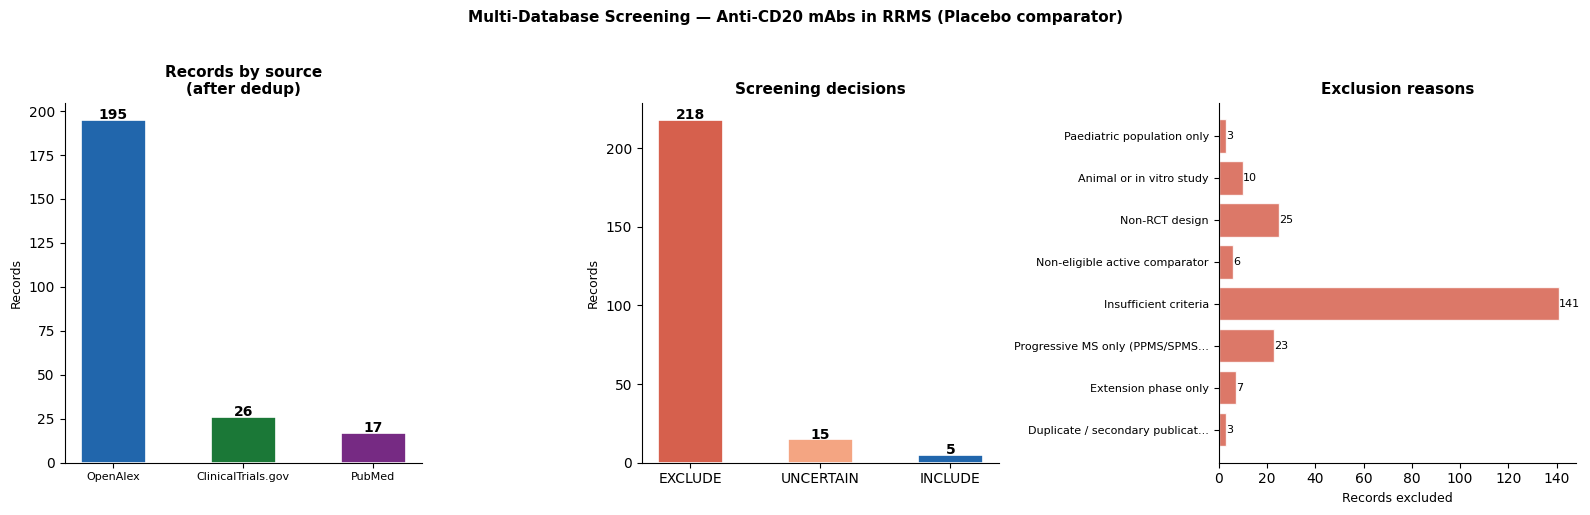

✓ screening_summary_chart.png saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')
COLORS = {'INCLUDE': '#2166ac', 'EXCLUDE': '#d6604d', 'UNCERTAIN': '#f4a582'}

# Plot 1: Source breakdown
ax1 = axes[0]
src_counts = df_dedup['source'].value_counts()
src_colors = ['#2166ac','#1b7837','#762a83','#b35806']
ax1.bar(src_counts.index, src_counts.values,
        color=src_colors[:len(src_counts)], edgecolor='white', linewidth=1.2, width=0.5)
for i, (src, cnt) in enumerate(src_counts.items()):
    ax1.text(i, cnt + 0.3, str(cnt), ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Records by source\n(after dedup)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Records', fontsize=9)
ax1.tick_params(axis='x', labelsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot 2: Screening decisions
ax2 = axes[1]
dec_counts = df_dedup['final_decision'].value_counts()
bar_colors = [COLORS.get(d,'#888') for d in dec_counts.index]
bars = ax2.bar(dec_counts.index, dec_counts.values,
               color=bar_colors, edgecolor='white', linewidth=1.2, width=0.5)
for bar, cnt in zip(bars, dec_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(cnt), ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Screening decisions', fontsize=11, fontweight='bold')
ax2.set_ylabel('Records', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Plot 3: Exclusion reasons
ax3 = axes[2]
excluded_df = df_dedup[df_dedup['final_decision'] == 'EXCLUDE']
reason_counts = {}
for _, row in excluded_df.iterrows():
    triggers = str(row.get('exclusion_triggers',''))
    if triggers and triggers != 'nan':
        first = triggers.split(';')[0].strip()
        label = first.split(':')[-1].strip() if ':' in first else first
    else:
        label = 'Insufficient criteria'
    reason_counts[label] = reason_counts.get(label, 0) + 1

if reason_counts:
    labels = list(reason_counts.keys())
    vals   = list(reason_counts.values())
    ypos   = range(len(labels))
    ax3.barh(ypos, vals, color='#d6604d', alpha=0.85, edgecolor='white')
    ax3.set_yticks(ypos)
    ax3.set_yticklabels([l[:30]+'...' if len(l)>30 else l for l in labels], fontsize=8)
    ax3.set_xlabel('Records excluded', fontsize=9)
    for i, v in enumerate(vals):
        ax3.text(v+0.05, i, str(v), va='center', fontsize=8)
ax3.set_title('Exclusion reasons', fontsize=11, fontweight='bold')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.suptitle('Multi-Database Screening — Anti-CD20 mAbs in RRMS (Placebo comparator)',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('screening_summary_chart.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ screening_summary_chart.png saved')